NOTE: Consider using SAMBUCA for IOPs, apparently more robubst to shallow scenes than QAA

In [21]:
import sys
sys.path.insert(0, "..")

import pystac
import numpy as np
import pandas as pd
import rioxarray as rxr
from pathlib import Path
from tqdm.notebook import tqdm
from rasterio.transform import rowcol
from scipy.ndimage import uniform_filter
from itertools import combinations
import skgstat as skg
import matplotlib.pyplot as plt
import rasterio
from scipy.spatial.distance import pdist

from scipy.spatial import cKDTree

from helpers.shared import assert_grid_match, normalised_diff, time_match

from plotnine import (
    ggplot, aes, geom_point, geom_smooth, geom_vline, theme_set, theme_light,
    facet_wrap, labs, theme_bw, theme, element_text, scale_x_continuous,
    geom_bin2d, scale_fill_continuous, geom_boxplot, geom_line, geom_hline
)

import math

In [22]:
from config import *

# -- Catalog --------------------------------------------------------------------------------------------
CATALOG                 = load_catalog()

INPUT_ASSET             = {
                            "bathy": "corrected-bathy",
                            "imagery": "norm",
                            "sg_pct" : "ard",
                            "sg_species": "ard"
                            }

# --- Bands ---
# norm assets have 4 bands (B, G, Y, R): CB, REdge, NIR dropped upstream in harm
NORM_BAND_NAMES = {
    "wv2-imagery": ["B", "G", "Y", "R"],
    "sd8-imagery": ["B", "G", "Y", "R"],
}

DROP_BANDS = {
    "wv2-imagery": [],
    "sd8-imagery": [],
}
# --- Features ---
SENSOR_BIN = {"wv2-imagery": 0, "sd8-imagery": 1}

# --- Algorithm Parameters ---
VARIO_SAMPLE_N = 2000
VARIO_BINS_N = 20

BATHY_RANGE = [-3, 0]

N_PER_CELL = 5_000

SPARSE_THRESHOLD = 0.5

# --- Output Options ---
OUT_DIR = Path("../out/stack/")

OUT_NAMES = {
                "tr": "train-stack",
                "val": "val-stack"
            }

OUT_EXT = "parquet"

# --- Execution Flags ---
OVERWRITE = True


In [23]:
img_items = [
    item for col_id in ["wv2-imagery", "sd8-imagery"]
    for item in CATALOG.get_child(col_id).get_items()
]

bathy_col = CATALOG.get_child("bathymetry")
bathy_items = [i for i in bathy_col.get_items()
               if INPUT_ASSET["bathy"] in i.assets]

sg_percov_items = list(CATALOG.get_child("seagrass-percov").get_items())
sg_species_items = list(CATALOG.get_child("seagrass-species").get_items())

all_items = (
    [(item, INPUT_ASSET["imagery"]) for item in img_items] +
    [(item, INPUT_ASSET["bathy"]) for item in bathy_items] +
    [(item, INPUT_ASSET["sg_pct"]) for item in sg_percov_items] +
    [(item, INPUT_ASSET["sg_species"]) for item in sg_species_items]
)

assert_grid_match(*[item.assets[key].href for item, key in all_items])

out = {}
for item, key in all_items:
    if key not in item.assets:
        continue
    tqdm.write(f"\nID: {item.id} | Date: {item.datetime} | Path: {item.assets[key].href}")
    da = rxr.open_rasterio(item.assets[key].href, chunks=CHUNKS)
    tqdm.write(f"  [Bands, H, W]: {da.shape} | CRS: {da.rio.crs}")
    out[item.id] = da


ID: wv2-20110610 | Date: 2011-06-10 00:30:00+00:00 | Path: C:/Users/samla/study/25-SEM3.ENVM7133/ENVM7133/out/norm/wv2-20110610-norm.tif
  [Bands, H, W]: (4, 7667, 4600) | CRS: EPSG:32756

ID: wv2-20120620 | Date: 2012-06-20 00:30:00+00:00 | Path: C:/Users/samla/study/25-SEM3.ENVM7133/ENVM7133/out/norm/wv2-20120620-norm.tif
  [Bands, H, W]: (4, 7667, 4600) | CRS: EPSG:32756

ID: wv2-20140714 | Date: 2014-07-14 00:30:00+00:00 | Path: C:/Users/samla/study/25-SEM3.ENVM7133/ENVM7133/out/norm/wv2-20140714-norm.tif
  [Bands, H, W]: (4, 7667, 4600) | CRS: EPSG:32756

ID: wv2-20150701 | Date: 2015-07-01 00:30:00+00:00 | Path: C:/Users/samla/study/25-SEM3.ENVM7133/ENVM7133/out/norm/wv2-20150701-norm.tif
  [Bands, H, W]: (4, 7667, 4600) | CRS: EPSG:32756

ID: sd8-20220713 | Date: 2022-07-13 23:13:22.862989+00:00 | Path: C:/Users/samla/study/25-SEM3.ENVM7133/ENVM7133/out/norm/sd8-20220713-norm.tif
  [Bands, H, W]: (4, 7667, 4600) | CRS: EPSG:32756

ID: sd8-20230706 | Date: 2023-07-06 23:22:24.86

In [24]:
matches = [
    (   
        bathy,
        time_match(img_items, bathy.datetime),
        time_match(sg_percov_items, bathy.datetime),
        time_match(sg_species_items, bathy.datetime)
    )
    for bathy in bathy_items
]

for bathy, img, percov, species in matches:
    tqdm.write(f"Match: {bathy.id} {bathy.datetime.date()} | {img.id} {img.datetime.date()} | {percov.id} {percov.datetime.date()} | {species.id} {species.datetime.date()}")

Match: bathy-201206 2012-06-01 | wv2-20120620 2012-06-20 | seagrass-percov-201207 2012-07-01 | seagrass-species-201207 2012-07-01
Match: bathy-202205 2022-05-01 | sd8-20220713 2022-07-13 | seagrass-percov-202205 2022-05-01 | seagrass-species-202205 2022-05-01


In [25]:
# stack bathy, seagrass, imgs

import xarray as xr

stacks = []

for bathy, img, percov, species in matches:
    img_col = img.collection_id
    band_names = NORM_BAND_NAMES[img_col]

    b_da = rxr.open_rasterio(bathy.assets[INPUT_ASSET["bathy"]].href, chunks=CHUNKS, masked = True).squeeze("band", drop=True)
    i_da = rxr.open_rasterio(img.assets[INPUT_ASSET["imagery"]].href, chunks=CHUNKS, masked = True)
    p_da = rxr.open_rasterio(percov.assets[INPUT_ASSET["sg_pct"]].href, chunks=CHUNKS, masked = True).squeeze("band", drop=True)
    s_da = rxr.open_rasterio(species.assets[INPUT_ASSET["sg_species"]].href, chunks=CHUNKS, masked = True).squeeze("band", drop=True)

    b_da = b_da.where((b_da >= BATHY_RANGE[0]) & (b_da <= BATHY_RANGE[1]))
    i_da = i_da.assign_coords(band = band_names)
    keep = [n for n in band_names if n not in DROP_BANDS[img_col]]
    i_da = i_da.sel(band = keep)

    ds = xr.Dataset({
        "elev": b_da,
        "sg_percov":  p_da,
        "sg_species": s_da,
        **{str(name): i_da.sel(band=name, drop=True) for name in i_da.coords["band"].values},
    })

    ds = ds.where(ds["elev"].notnull())
    stacks.append(ds)

datasets:   0%|          | 0/2 [00:00<?, ?it/s]

variograms:   0%|          | 0/7 [00:00<?, ?it/s]

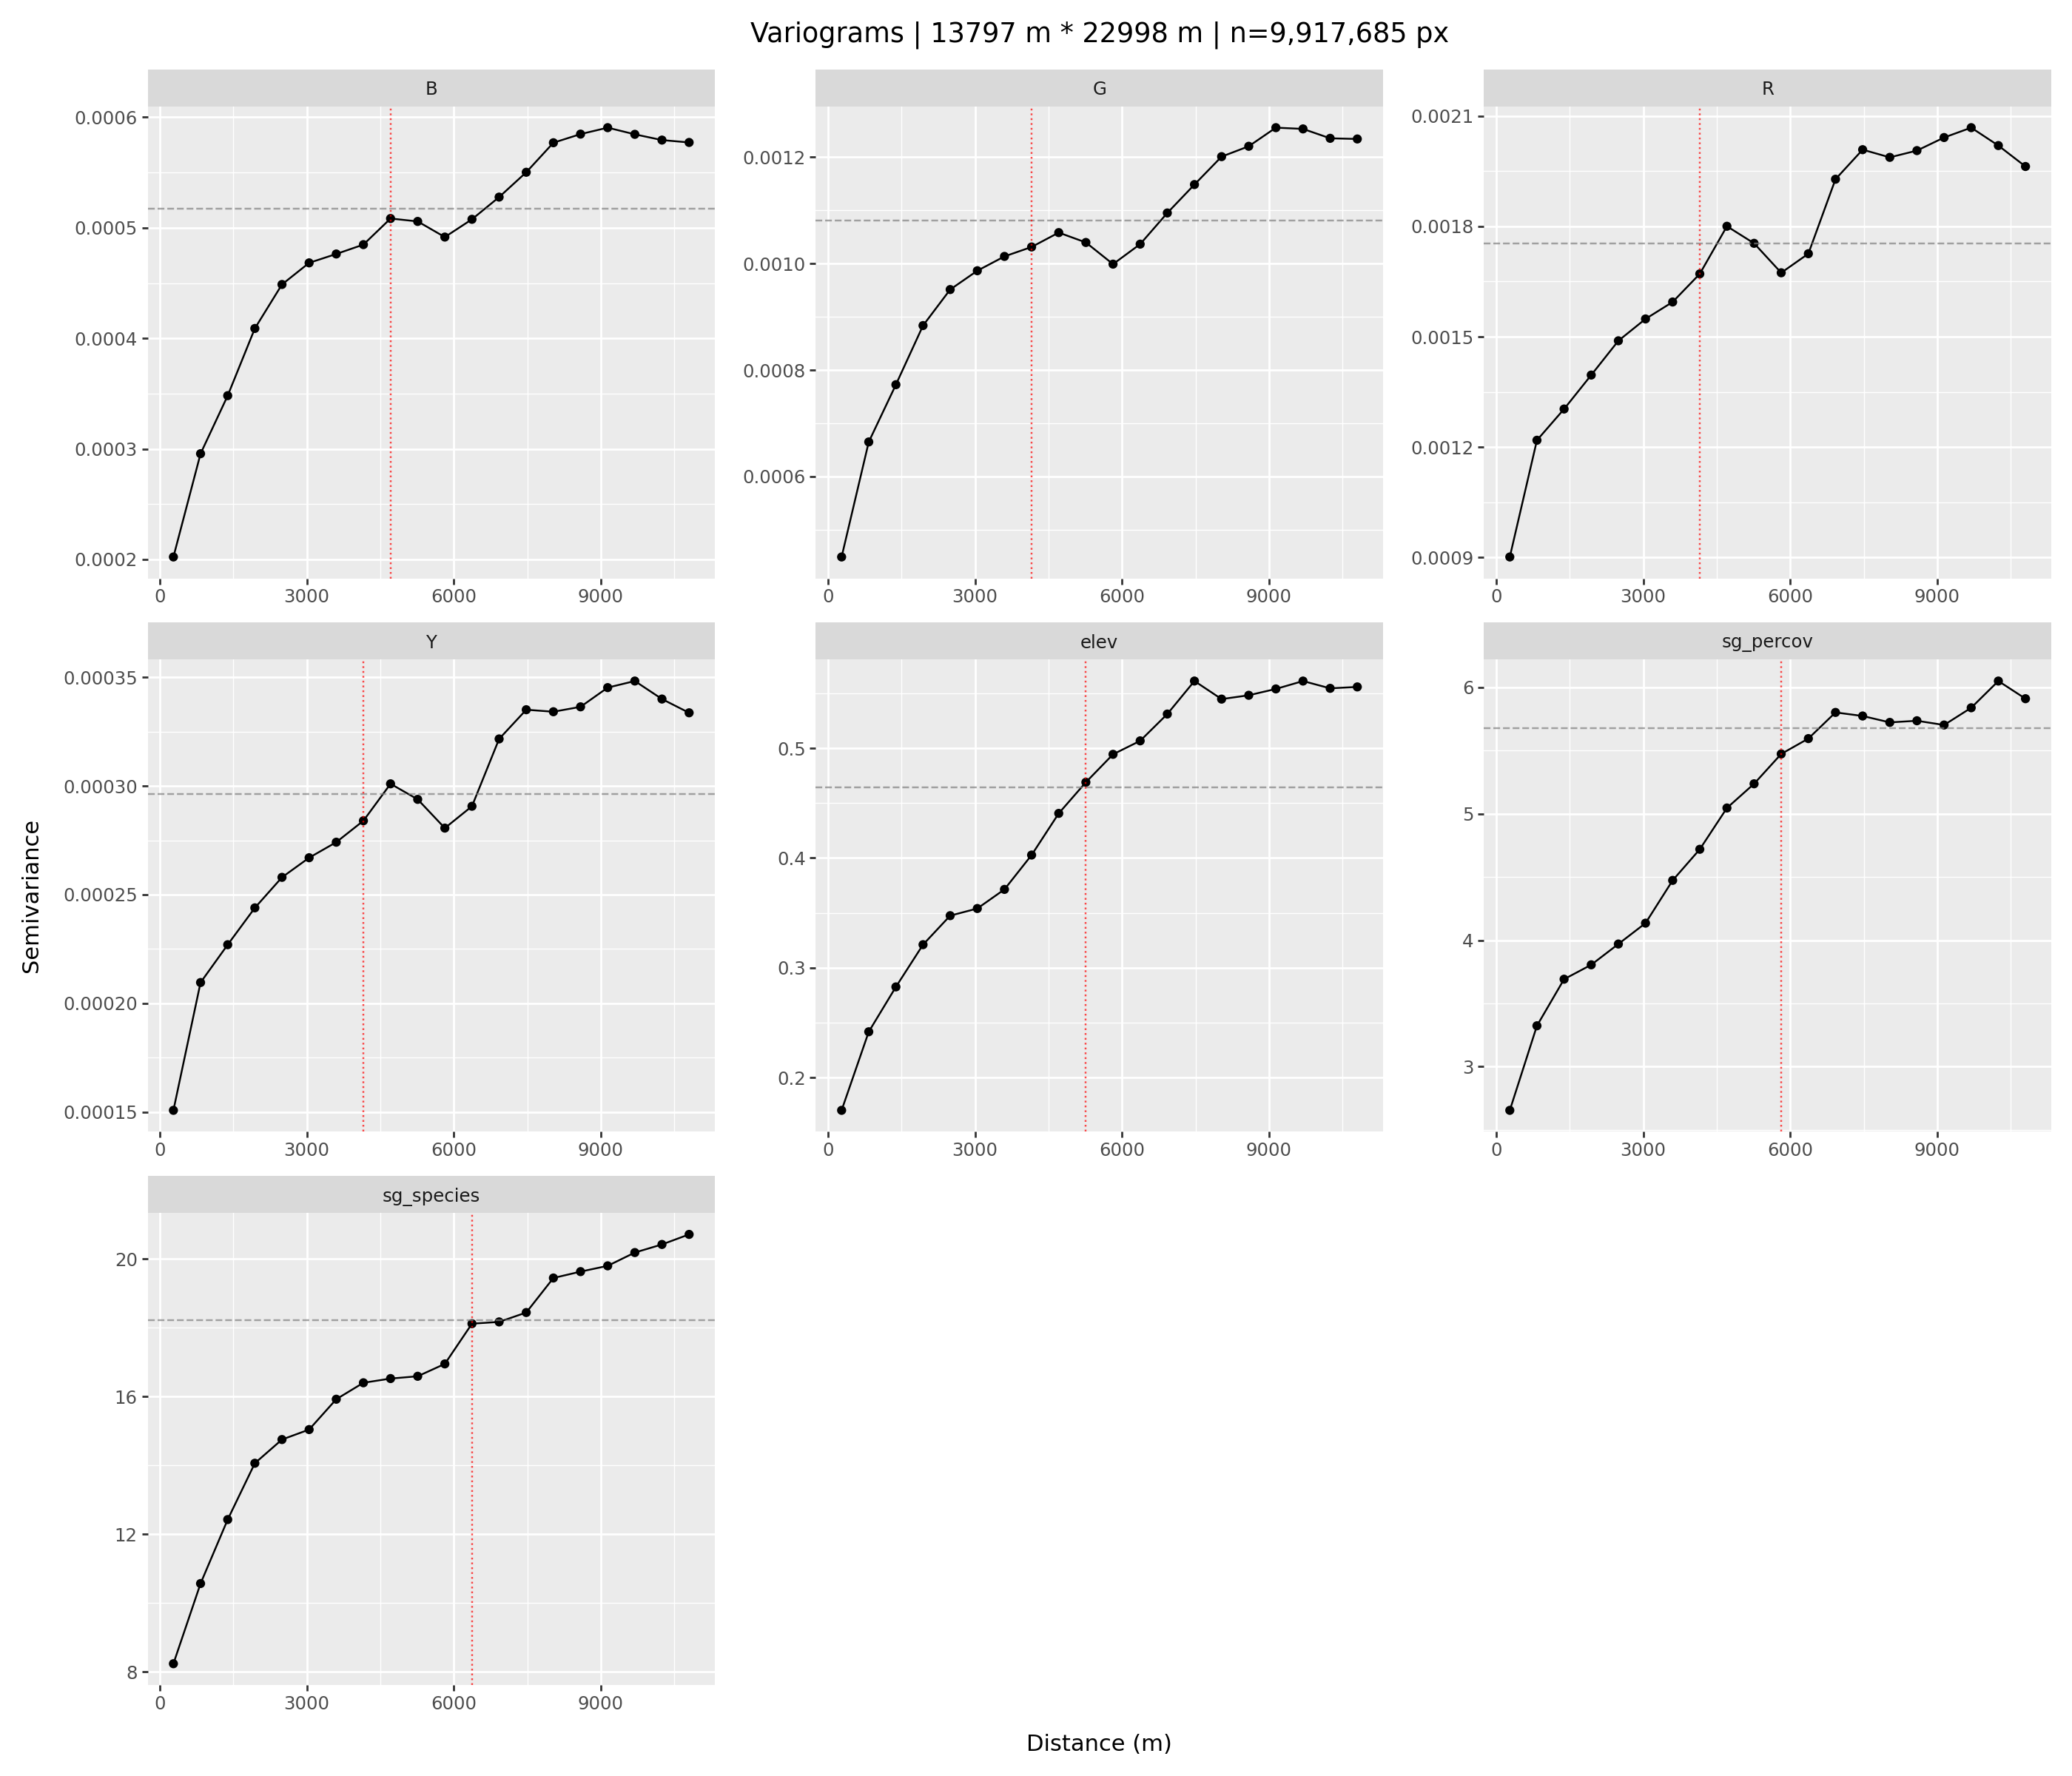

variograms:   0%|          | 0/7 [00:00<?, ?it/s]

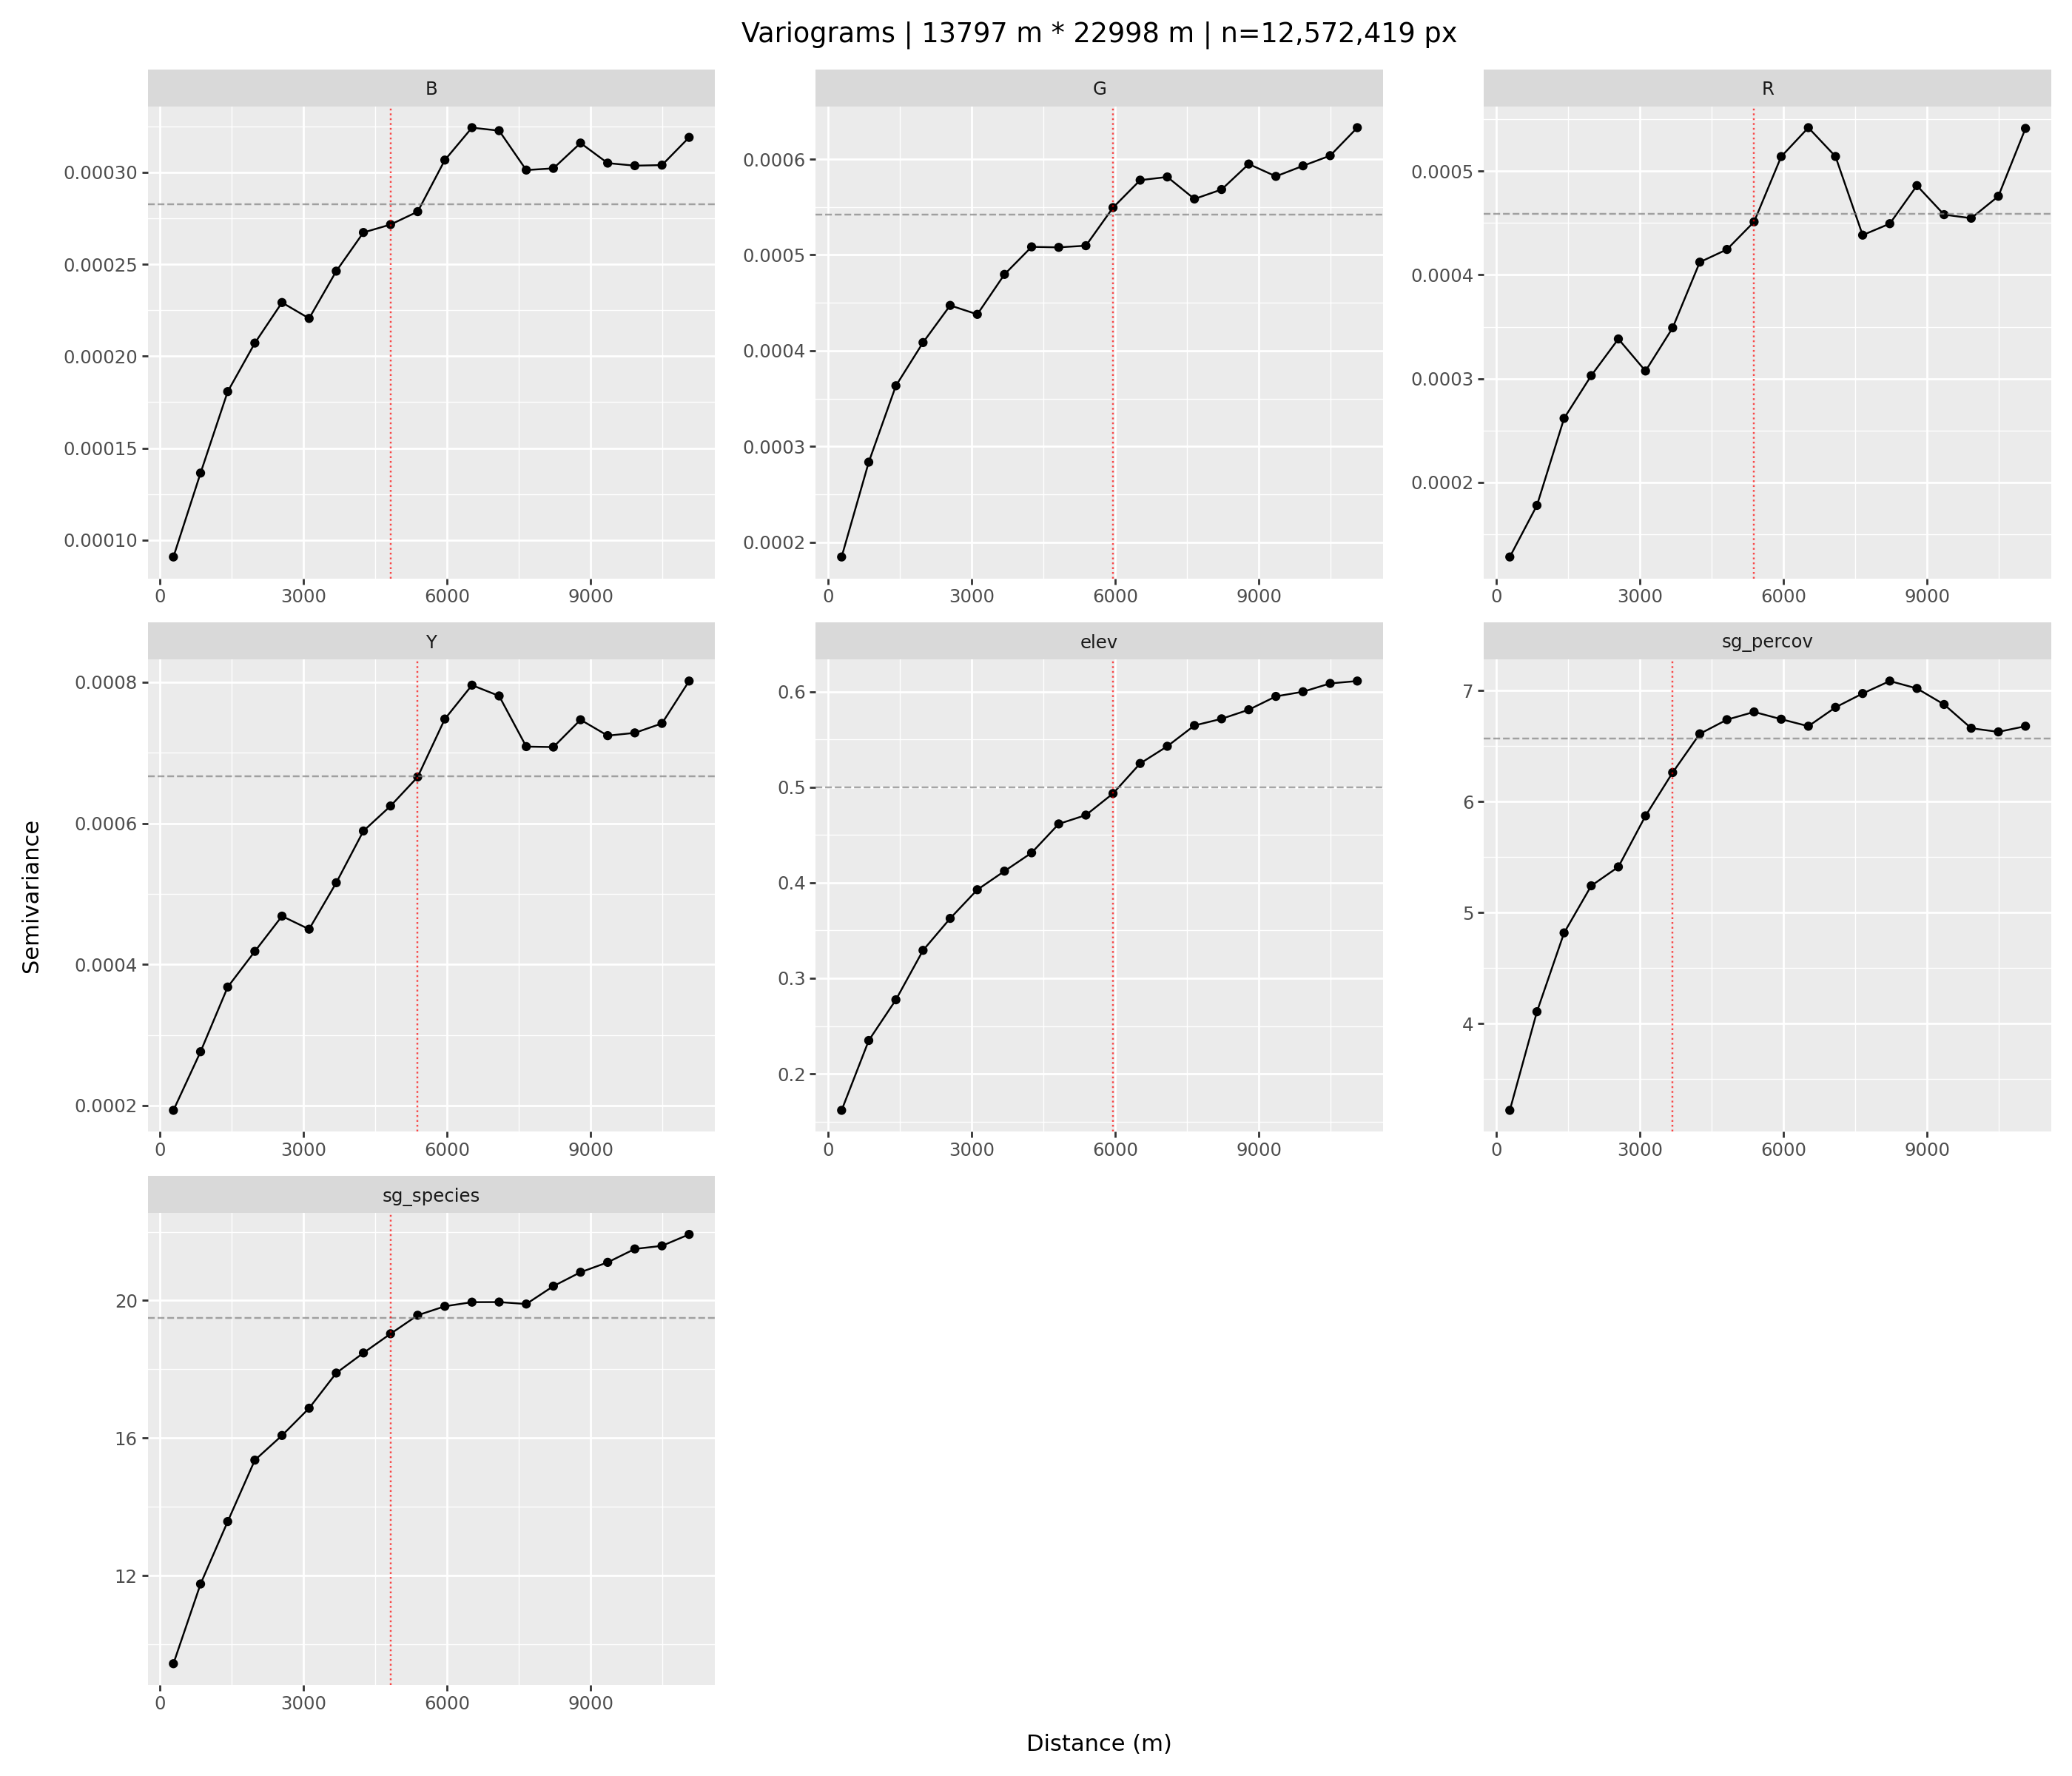

In [26]:
for ds in tqdm(stacks, desc="datasets"):
    df_v   = ds.to_dataframe().reset_index().dropna()
    sample = df_v.sample(n=min(VARIO_SAMPLE_N, len(df_v)), random_state=42)
    coords = sample[["x", "y"]].values
    dists  = pdist(coords)
    max_dist = np.percentile(dists, 80)
    bins     = np.linspace(0, max_dist, VARIO_BINS_N + 1)
    centers  = 0.5 * (bins[:-1] + bins[1:])

    variables  = list(ds.data_vars)
    vario_rows = []
    sill_rows  = []
    range_rows = []
    ranges     = {}

    for var in tqdm(variables, desc="variograms", leave=False):
        vals     = sample[var].values.astype(float)
        semivars = 0.5 * pdist(vals.reshape(-1, 1)) ** 2
        gamma    = np.array([
            semivars[(dists >= bins[i]) & (dists < bins[i+1])].mean()
            for i in range(VARIO_BINS_N)
        ])
        sill      = np.var(vals)
        hit       = np.where(gamma >= 0.95 * sill)[0]
        est_range = float(centers[hit[0]]) if len(hit) else np.nan
        ranges[var] = est_range

        vario_rows += [{"var": var, "distance": c, "gamma": g} for c, g in zip(centers, gamma)]
        sill_rows.append({"var": var, "sill": sill})
        if not np.isnan(est_range):
            range_rows.append({"var": var, "est_range": est_range})

    vario_df = pd.DataFrame(vario_rows)
    sill_df  = pd.DataFrame(sill_rows)
    range_df = pd.DataFrame(range_rows)

    x_ext = float(ds.x.max() - ds.x.min())
    y_ext = float(ds.y.max() - ds.y.min())

    p = (
        ggplot(vario_df, aes("distance", "gamma"))
        + geom_line()
        + geom_point(size=1.5)
        + geom_hline(aes(yintercept="sill"), data=sill_df,
                     linetype="dashed", color="grey", alpha=0.7)
        + geom_vline(aes(xintercept="est_range"), data=range_df,
                     linetype="dotted", color="red", alpha=0.7)
        + facet_wrap("var", scales="free", ncol=3)
        + labs(x="Distance (m)", y="Semivariance",
               title=f"Variograms | {x_ext:.0f} m * {y_ext:.0f} m | n={len(df_v):,} px")
        + theme(figure_size=(14, 4 * math.ceil(len(variables) / 3)))
    )
    
    display(p)


In [27]:
# for ds in tqdm(stacks, desc="datasets"):
#     df_v = (
#       ds.to_dataframe()
#         .reset_index()
#         .dropna()
#     )

#     sample   = df_v.sample(n=min(VARIO_SAMPLE_N, len(df_v)), random_state=42)
#     coords   = sample[["x", "y"]].values
#     dists    = pdist(coords)
#     max_dist = np.percentile(dists, 80)
#     bins     = np.linspace(0, max_dist, VARIO_BINS_N + 1)
#     centers  = 0.5 * (bins[:-1] + bins[1:])

#     variables = list(ds.data_vars)
#     ncols = 3
#     nrows = int(np.ceil(len(variables) / ncols))
#     fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
#     axes = axes.flatten()

#     ranges = {}

#     for ax, var in tqdm(zip(axes, variables), desc="variograms", total=len(variables), leave=False):
#         vals     = sample[var].values.astype(float)
#         semivars = 0.5 * pdist(vals.reshape(-1, 1)) ** 2
#         gamma    = np.array([
#             semivars[(dists >= bins[i]) & (dists < bins[i + 1])].mean()
#             for i in range(VARIO_BINS_N)
#         ])
#         sill = np.var(vals)
#         hit  = np.where(gamma >= 0.95 * sill)[0]
#         est_range = float(centers[hit[0]]) if len(hit) else np.nan
#         ranges[var] = est_range

#         ax.plot(centers, gamma, "o-")
#         ax.axhline(sill, color="grey", linestyle="--", alpha=0.5, label="sill")
#         if not np.isnan(est_range):
#             ax.axvline(est_range, color="red", linestyle=":", alpha=0.7, label=f"range {est_range:.0f} m")
#         ax.set_title(var)
#         ax.set_xlabel("Distance (m)")
#         ax.set_ylabel("Semivariance")
#         ax.legend(fontsize=7)

#     for ax in axes[len(variables):]:
#         ax.set_visible(False)

#     x_ext = float(ds.x.max() - ds.x.min())
#     y_ext = float(ds.y.max() - ds.y.min())
#     plt.suptitle(f"Variograms | extent {x_ext:.0f} m x {y_ext:.0f} m | n={len(df_v):,} valid px")
#     plt.tight_layout()
#     plt.show()

In [28]:
range_df = pd.DataFrame.from_dict(ranges, orient="index", columns=["range_m"]).sort_values("range_m")
BLOCK_SIZE = int(np.ceil(range_df["range_m"].max()))
display(range_df)
tqdm.write(f"BLOCK_SIZE: {BLOCK_SIZE} m")

,range_m
sg_percov,3685.552154
sg_species,4819.568202
B,4819.568202
Y,5386.576226
R,5386.576226
elev,5953.584249
G,5953.584249


BLOCK_SIZE: 5954 m


In [29]:
import importlib.util
from types import ModuleType
from pathlib import Path

sys.modules.setdefault('acolite', ModuleType('acolite'))

spec = importlib.util.spec_from_file_location(
    "p3qaa_compute",
    "../acolite/acolite/parameters/pitarch/p3qaa_compute.py"
)
_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(_mod)
p3qaa_compute = _mod.p3qaa_compute

P3QAA_SENSOR = {'wv2': 'WorldView2', 'sd8': 'PlanetScope_SD8'}
P3QAA_DIR = Path("../acolite/data/Shared/algorithms/P3QAA")

PARS = ['alpha','aw','bbw','beta1','beta2','bg_ratio','center_wl','chi','coef_z_sd']
p3qaa_cfg = {}
for par in PARS:
    with open(P3QAA_DIR / f"{par}.csv") as f:
        header = None
        for line in f:
            line = line.strip()
            if not line or line[0] in ['#', ';']: continue
            sp = line.split(',')
            if header is None: header = sp; continue
            sensor = sp[0]
            p3qaa_cfg.setdefault(sensor, {})[par] = d = {h: sp[i] for i,h in enumerate(header)}
            for k in ['p4','p3','p2','p1','p0','R','G','B']:
                if k in d: d[k] = float(d[k])

In [30]:
# qaa_coef = {}
# with open('../acolite/data/Shared/algorithms/QAA/qaa_settings.txt') as f:
#     for line in f:
#         line = line.strip()
#         if not line or line[0] in [';','!','/']: continue
#         if '=' in line:
#             k, v = line.split('=', 1)
#             if v in ('True','true'):    qaa_coef[k] = True
#             elif v in ('False','false'): qaa_coef[k] = False
#             elif ',' in v: qaa_coef[k] = [float(x) for x in v.split(',')]
#             else:
#                 try: qaa_coef[k] = float(v)
#                 except ValueError: qaa_coef[k] = v

# if 'useconfig' in qaa_coef:
#     for t in ['g','h','k','l','m']:
#         qaa_coef[t] = qaa_coef[f'{t}_{qaa_coef["useconfig"]}']

# spec = importlib.util.spec_from_file_location(
#     "qaa_compute", "../acolite/acolite/parameters/qaa/qaa_compute.py"
# )
# _mod = importlib.util.module_from_spec(spec)
# spec.loader.exec_module(_mod)
# qaa_compute = _mod.qaa_compute

# QAA_BAND_IDX = {
#     'wv2': (0, 1, 2, 4),   # CB, B, G, R  (443≈425, 490≈480, 560≈548, 665≈660)
#     'sd8': (0, 1, 3, 5),   # CB, B, G2, R (443, 490, 560≈565, 665)
# }

In [31]:
# # load lookup tables once (in setup cell)
# _tables  = np.load("../data/misc/uqaa/uqaa_tables.npz")
# _AW_WL   = _tables['aw_wl'];   _AW   = _tables['aw']
# _APHI_WL = _tables['aphi_wl']; _A0   = _tables['a0']; _A1 = _tables['a1']

# def decompose_iops(a, wl, S_cdom=0.015):
#     """
#     a   : (n_pixels, n_bands) total absorption from QAA
#     wl  : (n_bands,) wavelengths in nm
#     Returns C [mg m-3], ag440 [m-1]
#     """
#     wl  = np.asarray(wl, dtype=float)
#     aw  = np.interp(wl, _AW_WL,   _AW)
#     a0  = np.interp(wl, _APHI_WL, _A0)
#     a1  = np.interp(wl, _APHI_WL, _A1)
#     cdom_shape = np.exp(-S_cdom * (wl - 440))

#     da     = a - aw[None, :]
#     aph440 = np.full(a.shape[0], 0.05)

#     for _ in range(10):
#         phi  = (a0 + a1 * np.log(np.maximum(aph440[:, None], 1e-9)))
#         A    = np.stack([phi, np.broadcast_to(cdom_shape, phi.shape)], axis=2)
#         AtA  = np.einsum('nbi,nbj->nij', A, A)
#         Atb  = np.einsum('nbi,nb->ni',  A, da)
#         x    = np.linalg.solve(AtA, Atb)
#         aph440_new = np.maximum(x[:, 0], 1e-6)
#         ag440      = np.maximum(x[:, 1], 1e-6)
#         if np.max(np.abs(aph440_new - aph440)) < 1e-6:
#             break
#         aph440 = aph440_new

#     C = (aph440 / 0.06) ** (1 / 0.65)
#     return np.clip(C, 0, 50), np.clip(ag440, 0, 3)

In [32]:
sampled = []

for bathy, img, percov, species in tqdm(matches, desc="matches"):
    img_col    = img.collection_id
    all_names  = NORM_BAND_NAMES[img_col]
    keep_names = [n for n in all_names if n not in DROP_BANDS[img_col]]
    keep_idx   = [i for i, n in enumerate(all_names) if n not in DROP_BANDS[img_col]]

    # --- Load only what we need for straification -> keep mem down ---
    b_da = rxr.open_rasterio(bathy.assets[INPUT_ASSET["bathy"]].href, chunks=CHUNKS, masked = True).squeeze("band", drop=True)
    p_da = rxr.open_rasterio(percov.assets[INPUT_ASSET["sg_pct"]].href, chunks=CHUNKS, masked = True).squeeze("band", drop=True)

    valid = (
        (b_da >= BATHY_RANGE[0])
        & (b_da <= BATHY_RANGE[1])
        & b_da.notnull() & p_da.notnull()
    )

    idx_df = (
        xr.Dataset({"elev": b_da, "sg_percov": p_da})
        .where(valid)
        .to_dataframe()
        .reset_index()[["x", "y", "elev", "sg_percov"]]
        .dropna(subset=["elev", "sg_percov"])
        .reset_index(drop=True)
    )

    idx_df["block_x"] = ((idx_df["x"] - idx_df["x"].min()) // BLOCK_SIZE).astype(int)
    idx_df["block_y"] = ((idx_df["y"] - idx_df["y"].min()) // BLOCK_SIZE).astype(int)

    # --- Convert to int ---
    n_cols = idx_df["block_x"].max() + 1
    idx_df["block_id"] = idx_df["block_y"] * n_cols + idx_df["block_x"]


    # --- Sample ---

    sample = (
        idx_df.groupby(["block_id", "sg_percov"], group_keys=False)[idx_df.columns]
          .apply(lambda g: g.sample(n=min(N_PER_CELL, len(g)), random_state=42))
          .reset_index(drop=True)
    )

    # stratify by percov?

    # --- Read img and species at sampled coords ---
    coords = list(zip(sample["x"], sample["y"]))

    with rasterio.open(img.assets[INPUT_ASSET["imagery"]].href) as i_src:
        i_vals = np.array(list(i_src.sample(coords)))

    with rasterio.open(species.assets[INPUT_ASSET["sg_species"]].href) as s_src:
        s_vals = np.array(list(s_src.sample(coords)))[:, 0]

    for i, name in zip(keep_idx, keep_names):
        sample[name] = i_vals[:, i]

    sample["sg_species"] = s_vals

    # --- Sensor binary ---
    sample["sensor"] = SENSOR_BIN[img_col]
    sample["tide_h"] = img.extra_fields["tide_height_m"]

    # --- p3qaa ---

    B = sample["B"].values.astype(float)
    G = sample["G"].values.astype(float)
    R = sample["R"].values.astype(float)

    water = np.all((np.stack([B, G, R]) > 0) & np.isfinite(np.stack([B, G, R])), axis=0)

    iop_cols = ['a_B','a_G','a_R','Kd_G','zSD']
    for col in iop_cols:
        sample[col] = np.nan

    if water.sum() > 0:
        res = p3qaa_compute(
            P3QAA_SENSOR[img_col[:3]], B[water], G[water], R[water],
            cfg=p3qaa_cfg
        )
        a = res['a'].squeeze()
        Kd = res['Kd'].squeeze()
        zSD = res['zSD'].squeeze()

        sample.loc[water, 'a_B'] = a[:,0]
        sample.loc[water, 'a_G'] = a[:,1]
        sample.loc[water, 'a_R'] = a[:,2]
        sample.loc[water, 'Kd_G'] = np.clip(Kd[:,1], 0, 20)
        sample.loc[water, 'zSD']  = np.clip(zSD, 0, None)


    # --- QAA ---

    # cb_i, b_i, g_i, r_i = QAA_BAND_IDX[img_col[:3]]
    # CB = i_vals[:, cb_i].astype(float)
    # B  = i_vals[:, b_i].astype(float)
    # G  = i_vals[:, g_i].astype(float)
    # R  = i_vals[:, r_i].astype(float)

    # water = np.all((np.stack([CB, B, G, R]) > 0) & np.isfinite(np.stack([CB, B, G, R])), axis=0)

    # iop_cols = ['a_443', 'a_490', 'a_560', 'Kd_490', 'Zeu', 'C', 'ag440']
    # for col in iop_cols:
    #     sample[col] = np.nan

    # if water.sum() > 0:
    #     qaa_in = {443: CB[water], 490: B[water], 560: G[water], 665: R[water]}
    #     res = qaa_compute(qaa_in, sza=0, qaa_coef=qaa_coef)

    #     sample.loc[water, 'a_443']  = np.clip(res['v6_a_443'],  0, 20)
    #     sample.loc[water, 'a_490']  = np.clip(res['v6_a_490'],  0, 20)
    #     sample.loc[water, 'a_560']  = np.clip(res['v6_a_560'],  0, 10)
    #     sample.loc[water, 'Kd_490'] = np.clip(res['v6_Kd_490'], 0, 20)
    #     sample.loc[water, 'Zeu']    = np.clip(res['v6_Zeu_Lee'], 0, 50)

    #     a_valid = np.stack(
    #         [res['v6_a_443'], res['v6_a_490'], res['v6_a_560'], res['v6_a_665']], axis=1
    #     )
    #     C, ag440 = decompose_iops(a_valid, wl=[443, 490, 560, 665])
    #     sample.loc[water, 'C']     = C      # clipped to [0, 50] in decompose_iops
    #     sample.loc[water, 'ag440'] = ag440  # clipped to [0,  3] in decompose_iops

    sampled.append(sample)

sampled_df = pd.concat(sampled, ignore_index = True)
tqdm.write(f"Sampled: {len(sampled_df)} rows | {sampled_df.shape[1]} cols")

matches:   0%|          | 0/2 [00:00<?, ?it/s]

Sampled: 674120 rows | 19 cols


In [33]:
print(f"Rows: {len(sampled_df):,} | Cols: {sampled_df.shape[1]}\n")

display(pd.crosstab(sampled_df["block_id"], sampled_df["sg_percov"].astype(int)))
display(sampled_df.describe().round(3))

with pd.option_context("display.max_columns", None):
    for sensor_val, sdf in sampled_df.groupby("sensor"):
        sensor_name = next(k for k, v in SENSOR_BIN.items() if v == sensor_val)
        print(f"\n=================== {sensor_name} (n={len(sdf):,}) ===================")
        display(sdf.describe().round(3))

# print(f"Rows: {len(sampled_df):,} | Cols: {sampled_df.shape[1]}\n")

# display(sampled_df.groupby("block_id").size().rename("n").to_frame())
# display(sampled_df.describe().round(3))

# with pd.option_context("display.max_columns", None):
#     for sensor_val, sdf in sampled_df.groupby("sensor"):
#         sensor_name = next(k for k, v in SENSOR_BIN.items() if v == sensor_val)
#         print(f"\n=================== {sensor_name} (n={len(sdf):,}) ===================")
#         display(sdf.describe().round(3))

Rows: 674,120 | Cols: 19



sg_percov,0,1,2,3,4,5,6,7
block_id,,,,,,,,
0,10000,10000,10000,10000,10000,10000,6910,10000
1,10000,10000,10000,10000,10000,10000,10000,10000
2,919,0,0,0,196,0,5000,448
3,10000,10000,10000,10000,10000,10000,9239,10000
4,10000,10000,10000,10000,10000,10000,10000,10000
5,5283,10000,7215,3351,10000,6211,10000,10000
6,10000,10000,10000,5520,4219,5008,5000,10000
7,10000,10000,10000,10000,10000,10000,10000,10000
8,10000,5000,5000,3292,5000,5000,5000,5000


,x,y,elev,sg_percov,block_x,block_y,block_id,B,G,Y,R,sg_species,sensor,tide_h,a_B,a_G,a_R,Kd_G,zSD
count,674120.000,674120.000,674120.000,674120.000,674120.000,674120.000,674120.000,665849.000,665849.000,665849.000,665849.000,674120.000,674120.000,674120.000,665338.000,665338.000,665338.000,665338.000,665338.000
mean,538508.934,6969211.847,-1.746,3.444,0.832,1.344,4.865,0.039,0.057,0.034,0.034,5.862,0.509,1.769,0.676,0.281,0.625,2.330,0.755
std,2901.292,5436.788,0.801,2.361,0.705,1.013,3.224,0.024,0.032,0.029,0.041,4.187,0.500,0.048,37.460,0.240,7.943,3.594,0.620
min,530137.500,6958273.500,-3.000,0.000,0.000,0.000,0.000,0.000,0.003,0.000,0.000,0.000,0.000,1.720,0.012,0.065,0.402,0.000,0.000
25%,536140.500,6964426.500,-2.468,1.000,0.000,1.000,3.000,0.024,0.038,0.018,0.014,2.000,0.000,1.720,0.284,0.171,0.428,0.794,0.319
50%,538057.500,6968233.500,-1.729,3.000,1.000,1.000,5.000,0.032,0.049,0.026,0.021,5.000,1.000,1.816,0.391,0.216,0.519,1.178,0.652
75%,541009.500,6973357.500,-1.073,6.000,1.000,2.000,7.000,0.046,0.069,0.039,0.036,11.000,1.000,1.816,0.555,0.296,0.666,2.159,1.019
max,543682.500,6980962.500,-0.020,7.000,2.000,3.000,11.000,0.347,0.443,0.553,0.525,12.000,1.000,1.816,29881.465,33.719,4927.644,20.000,18.398



=================== wv2-imagery (n=330,963) ===================


,x,y,elev,sg_percov,block_x,block_y,block_id,B,G,Y,R,sg_species,sensor,tide_h,a_B,a_G,a_R,Kd_G,zSD
count,330963.000,330963.000,330963.000,330963.000,330963.000,330963.000,330963.000,322692.000,322692.000,322692.000,322692.000,330963.000,330963.0,330963.00,322181.000,322181.000,322181.000,322181.000,322181.000
mean,538407.265,6969388.562,-1.852,3.451,0.700,1.382,4.846,0.043,0.060,0.028,0.044,6.100,0.0,1.72,0.854,0.314,0.552,2.985,0.796
std,2805.831,5524.931,0.808,2.360,0.653,1.044,3.260,0.025,0.033,0.020,0.049,4.131,0.0,0.00,53.659,0.300,11.250,4.671,0.787
min,531190.500,6958273.500,-3.000,0.000,0.000,0.000,0.000,0.008,0.003,0.003,0.000,0.000,0.0,1.72,0.012,0.065,0.402,0.000,0.000
25%,536449.500,6964474.500,-2.608,1.000,0.000,1.000,3.000,0.027,0.036,0.016,0.016,3.000,0.0,1.72,0.223,0.145,0.402,0.687,0.257
50%,537724.500,6968197.500,-1.885,3.000,1.000,1.000,5.000,0.037,0.053,0.022,0.028,5.000,0.0,1.72,0.352,0.213,0.424,1.277,0.567
75%,540418.500,6974482.500,-1.297,6.000,1.000,2.000,7.000,0.051,0.073,0.032,0.049,11.000,0.0,1.72,0.622,0.350,0.475,2.620,1.106
max,543682.500,6978652.500,-0.020,7.000,2.000,3.000,11.000,0.308,0.249,0.236,0.335,12.000,0.0,1.72,29881.465,8.238,4927.644,20.000,18.398



=================== sd8-imagery (n=343,157) ===================


,x,y,elev,sg_percov,block_x,block_y,block_id,B,G,Y,R,sg_species,sensor,tide_h,a_B,a_G,a_R,Kd_G,zSD
count,343157.000,343157.000,343157.000,343157.000,343157.000,343157.000,343157.000,343157.000,343157.000,343157.000,343157.000,343157.000,343157.0,343157.000,343157.000,343157.000,343157.000,343157.000,343157.000
mean,538606.991,6969041.412,-1.644,3.437,0.959,1.308,4.883,0.035,0.055,0.038,0.024,5.632,1.0,1.816,0.508,0.251,0.693,1.715,0.716
std,2987.204,5344.876,0.780,2.362,0.729,0.981,3.189,0.023,0.030,0.035,0.030,4.227,0.0,0.000,4.161,0.157,1.870,1.944,0.402
min,530137.500,6958273.500,-3.000,0.000,0.000,0.000,0.000,0.000,0.008,0.000,0.000,0.000,1.0,1.816,0.015,0.089,0.431,0.000,0.000
25%,535936.500,6964387.500,-2.341,1.000,0.000,1.000,3.000,0.023,0.038,0.021,0.012,2.000,1.0,1.816,0.332,0.184,0.568,0.843,0.394
50%,538540.500,6968311.500,-1.595,3.000,1.000,1.000,5.000,0.029,0.046,0.032,0.018,4.000,1.0,1.816,0.404,0.217,0.655,1.131,0.712
75%,541933.500,6972736.500,-0.940,6.000,1.000,2.000,7.000,0.041,0.065,0.045,0.027,11.000,1.0,1.816,0.518,0.268,0.759,1.821,0.988
max,543682.500,6980962.500,-0.098,7.000,2.000,3.000,11.000,0.347,0.443,0.553,0.525,12.000,1.0,1.816,1733.834,33.719,764.529,20.000,5.205


In [34]:
# sparse block merging

centroids = (
    sampled_df.groupby("block_id")[["x", "y"]]
    .mean()
    .rename(columns={"x": "cx", "y": "cy"})
)

counts = sampled_df.groupby("block_id").size().rename("n")
threshold = counts.max() * SPARSE_THRESHOLD
sparse = counts[counts < threshold].index
dense = counts[counts >= threshold].index

dense_centroids = centroids.loc[dense][["cx", "cy"]].values
tree = cKDTree(dense_centroids)

print(f"Threshold: {threshold:,.0f} ({SPARSE_THRESHOLD*100:.0f}% of max={counts.max():,})")
print(f"\nSparse blocks ({len(sparse)}):")
print(counts.loc[sparse].sort_values().to_string())

remap = {}
for block_id in sparse:
    cx, cy = centroids.loc[block_id, ["cx", "cy"]]
    _, idx = tree.query([cx, cy])
    remap[block_id] = dense[idx]

sampled_df["block_id"] = sampled_df["block_id"].replace(remap)


print(sampled_df["block_id"].value_counts().sort_index())

Threshold: 40,000 (50% of max=80,000)

Sparse blocks (3):
block_id
2      6563
11     8461
9     17848
block_id
0      76910
1      86563
3      79239
4      80000
5      62060
6      59747
7      80000
8      43292
10    106309
Name: count, dtype: int64


In [41]:
display(
    sampled_df.groupby("sg_percov")["elev"]
    .describe()[["count", "min", "25%", "50%", "75%", "max"]]
    .round(2)
)

display(
    sampled_df.groupby("block_id")["elev"]
    .describe()[["count", "min", "25%", "50%", "75%", "max"]]
    .round(2)
)

,count,min,25%,50%,75%,max
sg_percov,,,,,,
0.0,94715.0,-3.0,-2.93,-2.66,-0.97,-0.02
1.0,87341.0,-3.0,-2.21,-1.62,-1.11,-0.04
2.0,82492.0,-3.0,-2.39,-1.71,-1.33,-0.15
3.0,73877.0,-3.0,-2.38,-1.75,-1.23,-0.31
4.0,78147.0,-3.0,-2.55,-1.58,-1.01,-0.20
5.0,77584.0,-3.0,-2.32,-1.85,-1.31,-0.05
6.0,79547.0,-3.0,-2.20,-1.42,-0.84,-0.02
7.0,91635.0,-3.0,-2.44,-1.84,-0.83,-0.02


,count,min,25%,50%,75%,max
block_id,,,,,,
0,76898.0,-3.0,-2.69,-2.43,-2.07,-0.04
1,85927.0,-3.0,-2.24,-1.50,-0.95,-0.02
3,79234.0,-3.0,-2.82,-2.50,-2.08,-0.02
4,78412.0,-3.0,-2.52,-1.78,-1.16,-0.02
5,56520.0,-3.0,-1.35,-0.73,-0.47,-0.02
6,59736.0,-3.0,-2.64,-2.23,-1.59,-0.45
7,79587.0,-3.0,-1.72,-1.32,-0.90,-0.02
8,43291.0,-3.0,-2.28,-1.43,-0.99,-0.02
10,105733.0,-3.0,-2.05,-1.43,-0.85,-0.02


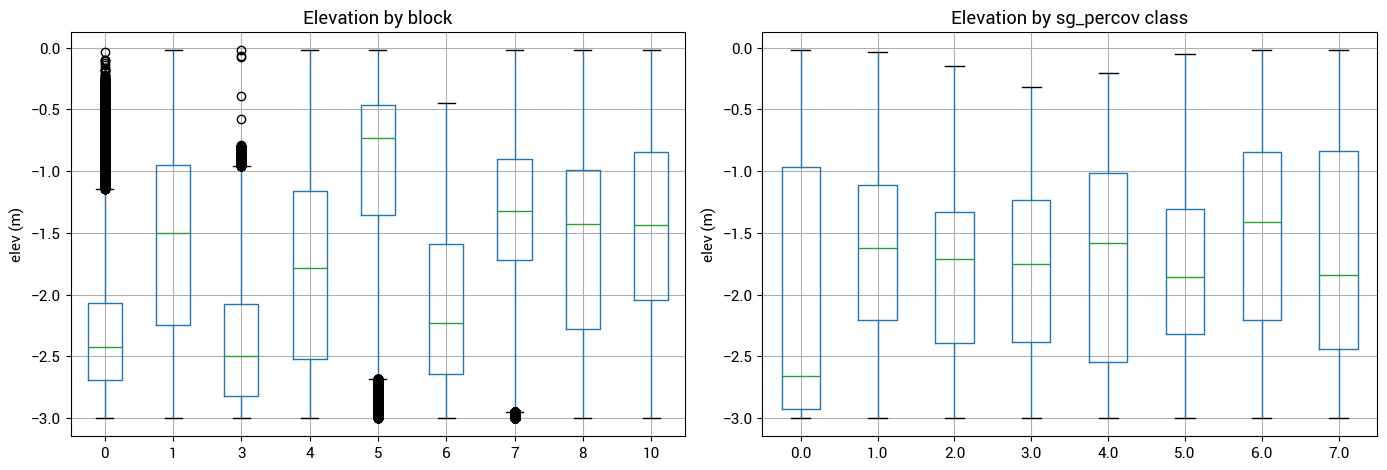

In [42]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sampled_df.boxplot(column="elev", by="block_id", ax=axes[0])
sampled_df.boxplot(column="elev", by="sg_percov", ax=axes[1])

axes[0].set_title("Elevation by block")
axes[1].set_title("Elevation by sg_percov class")
for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("elev (m)")

plt.suptitle("")
plt.tight_layout()
plt.show()


# Features

In [37]:
# log bands
for b in NORM_BAND_NAMES["wv2-imagery"]: # same bands
    sampled_df[f"log_{b}"] = np.log(sampled_df[b].where(sampled_df[b] > 0))

# # log ratios
# for b1, b2 in combinations(COMMON_BANDS, 2):
#     sampled_df[f"logR_{b1}_{b2}"] = (
#         np.log(sampled_df[b1].where(sampled_df[b1] > 0)) /
#         np.log(sampled_df[b2].where(sampled_df[b2] > 0))
#     )

# normalised diff
for b1, b2 in combinations(NORM_BAND_NAMES["wv2-imagery"], 2):
    sampled_df[f"nd_{b1}_{b2}"] = (
        (sampled_df[b1] - sampled_df[b2]) /
        (sampled_df[b1] + sampled_df[b2]).where((sampled_df[b1] + sampled_df[b2]) != 0)
    )

sampled_df.dropna(inplace=True)

In [38]:
out_name = OUT_NAMES["tr"]
out_path = OUT_DIR / f"{out_name}.{OUT_EXT}"
if out_path.exists() and not OVERWRITE:
    tqdm.write(f"Skipping (exists): {out_path.name}")

else:
    sampled_df.to_parquet(out_path, index = False)
    tqdm.write(f"Saved: {out_path.name}")
    
    stack_col = CATALOG.get_child("stacks")

    asset = pystac.Asset(
        href = str(out_path.resolve()),
        media_type = "application/x-parquet",
        title = "Training stack",
        roles = ["data"],
        description = "Stratified (block_id * sg_percov) sampled drawn from matched bathy-imagery pairs"
    )

    stack_col.add_asset(out_name, asset)

    CATALOG.normalize_hrefs(str(STAC_DIR))
    CATALOG.save(catalog_type=pystac.CatalogType.SELF_CONTAINED)
    tqdm.write(f"Catalog updated")
    tqdm.write(f"Complete")


Saved: train-stack.parquet
Catalog updated
Complete


# Val stack

In [39]:
# # We want to test val_df on the training range (different from max-min bathy range)
# TR_ELEV_RANGE = (sampled_df["elev"].min(), sampled_df["elev"].max())
# tqdm.write(f"Training elev range: [{TR_ELEV_RANGE[0]:.2f}, {TR_ELEV_RANGE[1]:.2f}] m")

In [40]:
# val = bathy_col.get_item("validation-bathy")
# img_match  = time_match(img_items, val.datetime)
# pct_match = time_match(sg_percov_items, val.datetime)
# sp_match = time_match(sg_species_items, val.datetime)

# print(img_match)

# img_col    = img_match.collection_id
# all_names  = ALL_BAND_NAMES[img_col]
# keep_names = [REASSIGN_BANDS.get(n, n) for n in all_names if n not in DROP_BANDS[img_col]]
# keep_idx   = [i for i, n in enumerate(all_names) if n not in DROP_BANDS[img_col]]

# v_da = rxr.open_rasterio(val.assets["validation-bathy"].href, chunks = CHUNKS, masked = True).squeeze("band", drop=True)

# valid = (
#     (v_da >= TR_ELEV_RANGE[0])
#     & (v_da <= TR_ELEV_RANGE[1])
#     & v_da.notnull()
# )

# val_df = (
#     v_da
#     .where(valid)
#     .to_dataframe(name="elev")
#     .reset_index()[["x", "y", "elev"]]
#     .dropna()
#     .reset_index(drop=True)
# )

# coords = list(zip(val_df["x"], val_df["y"]))

# with rasterio.open(img_match.assets[INPUT_ASSET["imagery"]].href) as i_src:
#     i_vals = np.array(list(i_src.sample(coords)))

# with rasterio.open(pct_match.assets[INPUT_ASSET["sg_pct"]].href) as p_src:
#     p_vals = np.array(list(p_src.sample(coords)))[:, 0]

# with rasterio.open(sp_match.assets[INPUT_ASSET["sg_species"]].href) as s_src:
#     s_vals = np.array(list(s_src.sample(coords)))[:, 0]

# for i, name in zip(keep_idx, keep_names):
#     val_df[name] = i_vals[:, i]

# val_df["sg_percov"]  = np.where(p_vals == 255, np.nan, p_vals)
# val_df["sg_species"] = np.where(s_vals == 255, np.nan, s_vals)
# val_df["sensor"] = SENSOR_BIN[img_col]
# val_df["tide_h"] = img_match.extra_fields["tide_height_m"]

# val_df.dropna(inplace=True)
# tqdm.write(f"Val rows: {len(val_df):,} | cols: {val_df.shape[1]}")

# for b in COMMON_BANDS:
#     val_df[f"log_{b}"] = np.log(val_df[b].where(val_df[b] > 0))

# for b1, b2 in combinations(COMMON_BANDS, 2):
#     val_df[f"nd_{b1}_{b2}"] = (
#         (val_df[b1] - val_df[b2]) /
#         (val_df[b1] + val_df[b2]).where((val_df[b1] + val_df[b2]) != 0)
#     )

# val_df.dropna(inplace=True)

# out_name = OUT_NAMES["val"]
# out_path = OUT_DIR / f"{out_name}.{OUT_EXT}"

# if out_path.exists() and not OVERWRITE:
#     tqdm.write(f"Skipping (exists): {out_path.name}")

# else:
#     val_df.to_parquet(out_path, index=False)
#     tqdm.write(f"Saved: {out_path.name}")

#     stack_col = CATALOG.get_child("stacks")
#     asset = pystac.Asset(
#         href = str(out_path.resolve()),
#         media_type  = "application/x-parquet",
#         title = "Validation stack",
#         roles = ["data"],
#         description = f"All valid pixels from boat-survey validation bathy matched to {img_match}"
#     )
#     stack_col.add_asset(out_name, asset)
#     CATALOG.normalize_hrefs(str(STAC_DIR))
#     CATALOG.save(catalog_type=pystac.CatalogType.SELF_CONTAINED)
#     tqdm.write("Catalog updated")